## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
Already up to date.


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [3]:
import os
import pandas as pd
import xgboost as xgb
from xgboost import XGBRanker
from xgboost import plot_importance
from sklearn.metrics import roc_auc_score

from Challenge.paths import load_xgboost_cv_folds, XGBOOST_DATAFRAMES
from Challenge.utils import evaluate_recommender
from Challenge.XGBoostReranker import XGBoostRerankerRecommender, ProgressCallback
from Challenge.XGBoostNative import XGBoostNativeRecommender

Running on local — storage at: /home/luigi/RecSys


## **Load Data**

In [4]:
_, URM_outer, _ = load_xgboost_cv_folds()
del _

In [5]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "training_data.parquet")

X_train = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
X_train

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/training_data.parquet


,UserID,ItemID,Label,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,ItemKNN_cosine_Score,ItemKNN_cosine_RankPosition,ItemKNN_cosine_Recommended,ItemKNN_jaccard_Score,...,Mean_RankPosition,Std_RankPosition,Skew_RankPosition,Kurtosis_RankPosition,Mean_Score,Std_Score,Skew_Score,Kurtosis_Score,User_Profile_Len,Item_Global_Popularity
0,0,13,0,0.041594,1324,0,0.239083,491,0,0.185018,...,752.299988,686.791260,1.021429,0.112598,0.103372,0.087700,1.070461,1.049027,58,357
1,0,13,0,0.043860,1286,0,0.253336,432,0,0.155972,...,1077.599976,913.856567,0.754376,-0.017597,0.065518,0.093295,-0.271691,1.054174,68,370
2,0,44,1,0.234533,148,0,0.552801,47,0,0.135240,...,1115.400024,2237.113037,2.100029,2.730972,0.180271,0.138595,0.880467,1.239617,58,2013
3,0,76,0,0.069006,855,0,0.396914,185,0,0.046504,...,304.799988,197.888214,1.310254,1.765815,0.148194,0.136293,1.099743,0.532424,68,594
4,0,86,0,0.314591,76,0,0.444792,133,0,0.111572,...,275.000000,475.798492,2.967940,8.367845,0.211813,0.157463,1.504626,2.449688,68,2708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19750164,27094,6945,0,0.010339,2863,0,0.283876,281,0,0.133982,...,478.850006,614.019714,3.393603,12.987067,0.200186,0.144557,1.052063,0.610949,192,89
19750165,27094,6945,0,0.009602,2980,0,0.248066,353,0,0.131175,...,527.049988,625.409485,3.512755,13.672679,0.192101,0.149848,1.300738,1.514217,199,81
19750166,27094,6945,0,0.010335,2859,0,0.242489,376,0,0.078403,...,900.650024,1414.640869,2.243805,3.900131,0.208701,0.195603,1.095990,0.495388,211,88
19750167,27094,6948,0,0.003851,4408,0,0.089030,1206,0,0.069272,...,1662.949951,1550.113159,1.135920,-0.307864,0.105512,0.130925,2.026733,4.362759,195,33


In [6]:
if not X_train['UserID'].is_monotonic_increasing:
    print("⚠️ Data is NOT sorted by UserID.")
    print("Sorting and overwriting file for future efficiency...")
    
    # Sort and reset index (critical for contiguous memory in ML)
    X_train = X_train.sort_values(by='UserID').reset_index(drop=True)
    
    # Overwrite the file on disk
    X_train.to_parquet(
        path=file_path,
        engine='fastparquet',
        compression='zstd',
        index=False
    )
    
    print(f"✅ Data sorted and saved to {file_path}")

In [7]:
assert X_train['UserID'].is_monotonic_increasing, "UserID column is not sorted in increasing order!"

# Group Calculation
groups = X_train.groupby("UserID").size().values

# Target and Feature Matrix Definition
y_train = X_train["Label"]

# Drop the identifiers (UserID, ItemID) and the target (Label), keeping only the features
X_train = X_train.drop(columns=["Label", "UserID", "ItemID"], errors='ignore')

# Make categorical features if any
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    X_train[col] = X_train[col].astype('category')

assert groups.sum() == X_train.shape[0], "Group sum does not match total data size!"

In [8]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "validation_data.parquet")

X_val = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

# Make categorical features if any
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    X_val[col] = X_val[col].astype('category')

print(f"Loaded successfully from: {file_path}")
X_val

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/validation_data.parquet


,UserID,ItemID,Label,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,ItemKNN_cosine_Score,ItemKNN_cosine_RankPosition,ItemKNN_cosine_Recommended,ItemKNN_jaccard_Score,...,Mean_RankPosition,Std_RankPosition,Skew_RankPosition,Kurtosis_RankPosition,Mean_Score,Std_Score,Skew_Score,Kurtosis_Score,User_Profile_Len,Item_Global_Popularity
0,0,13,0,0.042611,1293,0,0.209837,546,0,0.152503,...,807.000000,640.260010,0.396104,-1.387824,0.079952,0.072270,0.379061,-1.410258,80,455
1,0,89,0,0.207530,188,0,0.542487,38,0,0.183866,...,434.700012,781.701416,2.823948,6.798428,0.181923,0.163352,1.443109,1.847162,80,2216
2,0,225,0,0.090560,642,0,0.254757,402,0,0.176012,...,785.450012,805.496155,1.316501,0.903416,0.114576,0.112987,1.198424,1.003781,80,967
3,0,227,1,0.216333,178,0,0.456547,91,0,0.345323,...,518.150024,953.186829,1.626652,0.753078,0.274519,0.167467,-0.628666,-0.755620,80,2310
4,0,275,0,0.097677,589,0,0.533726,42,0,0.302773,...,93.800003,131.963943,3.189180,11.142217,0.283331,0.143117,0.452670,-0.617746,80,1043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3874150,27094,6624,0,0.555628,11,1,0.167659,642,0,0.213301,...,1657.050049,1946.286011,1.584614,1.367491,0.079645,0.169257,0.347632,3.573450,250,5933
3874151,27094,6724,0,0.021071,2002,0,0.322881,194,0,0.103405,...,290.000000,452.186615,3.172637,11.451586,0.280586,0.219803,1.064234,0.369629,250,225
3874152,27094,6771,0,0.383780,44,0,0.127183,889,0,0.099545,...,1709.099976,1784.538574,0.992725,-0.626230,0.094204,0.119647,-0.291556,2.981602,250,4098
3874153,27094,6810,0,0.253325,121,0,0.222065,423,0,0.080370,...,1446.400024,1776.171631,1.838771,2.804867,0.125290,0.155466,2.408205,7.939774,250,2705


## **Train Baseline**

In [9]:
# Hyperparameters (Your baseline configuration)
n_estimators = 100
learning_rate = 1e-1
reg_alpha = 1e-1
reg_lambda = 1e-1
max_depth = 5
grow_policy = "depthwise"
objective = "pairwise" 

XGB_model = XGBRanker(objective='rank:{}'.format(objective),
                      n_estimators = int(n_estimators),
                      random_state = 42, # Fixed seed for reproducibility
                      learning_rate = learning_rate,
                      reg_alpha = reg_alpha,
                      reg_lambda = reg_lambda,
                      max_depth = int(max_depth),
                      max_leaves = 0,
                      grow_policy = grow_policy,
                      verbosity = 1, # Set to 1 to see training progress
                      booster = "gbtree",
                      n_jobs=-1, # Use all cores

                      enable_categorical=True,
                      callbacks=[ProgressCallback(n_estimators)]
                      )

In [10]:
print(f"Starting XGBRanker training with {len(groups)} user groups...")

XGB_model.fit(X_train,
              y_train,
              group=groups
              )

Starting XGBRanker training with 27095 user groups...
[Training] Tree 100/100

,objective,'rank:pairwise'
,base_score,None
,booster,'gbtree'
,callbacks,[<Challenge.XG...x7f3fd2ec0050>]
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## **Score**

In [11]:
# Evaluate training performance
y_pred_scores = XGB_model.predict(X_train)
auc_score = roc_auc_score(y_train, y_pred_scores)
print(f"Training AUC Score: {auc_score:.4f}")

Training AUC Score: 0.7631


In [12]:
# Instantiate the recommender with the trained XGB model
recommender_instance = XGBoostRerankerRecommender(
    XGB_model=XGB_model,
    df=X_val
)
    
# Evaluate
score = evaluate_recommender(recommender_instance, at=20, URM_validation=URM_outer)
print(f"Validation Score (RECALL@20): {score:.4f}")

Eval Batches: 100%|██████████| 28/28 [00:02<00:00,  9.64it/s]

Validation Score (RECALL@20): 0.2931


## **Plots**

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

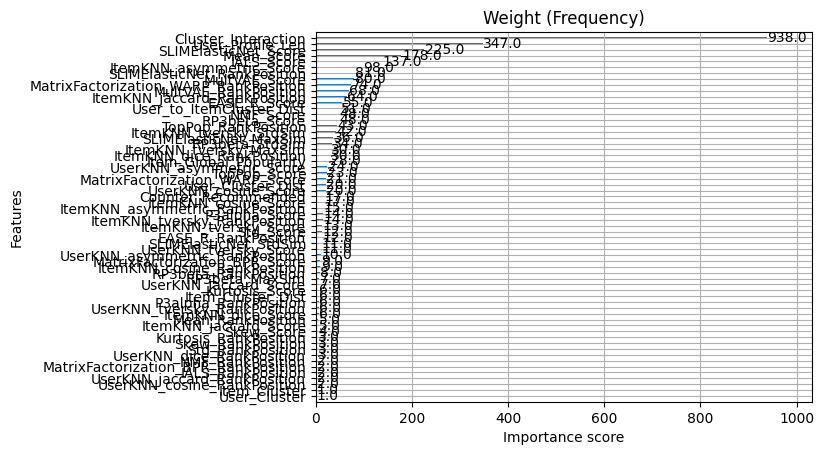

In [13]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')

<Axes: title={'center': 'Gain'}, xlabel='Importance score', ylabel='Features'>

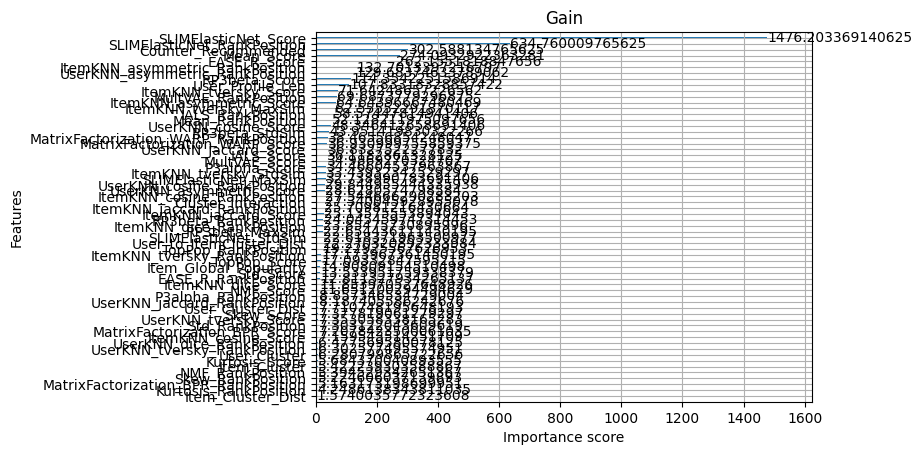

In [14]:
plot_importance(XGB_model, importance_type='gain', title='Gain')

<Axes: title={'center': 'Cover'}, xlabel='Importance score', ylabel='Features'>

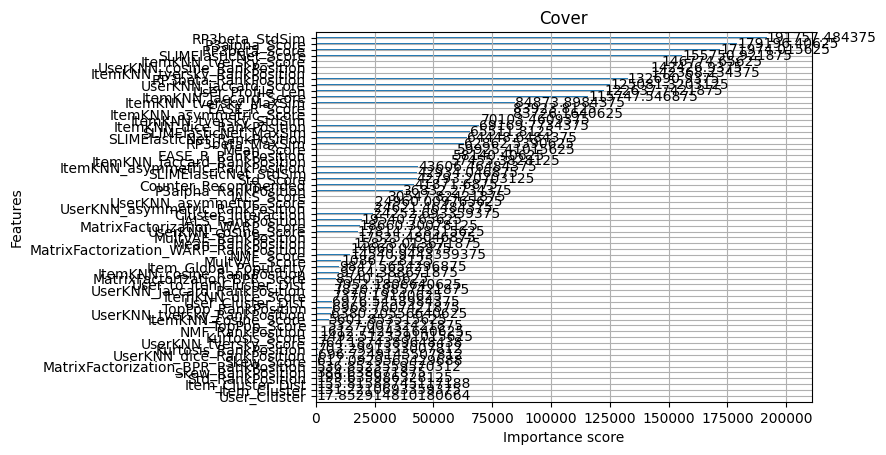

In [15]:
plot_importance(XGB_model, importance_type='cover', title='Cover')

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

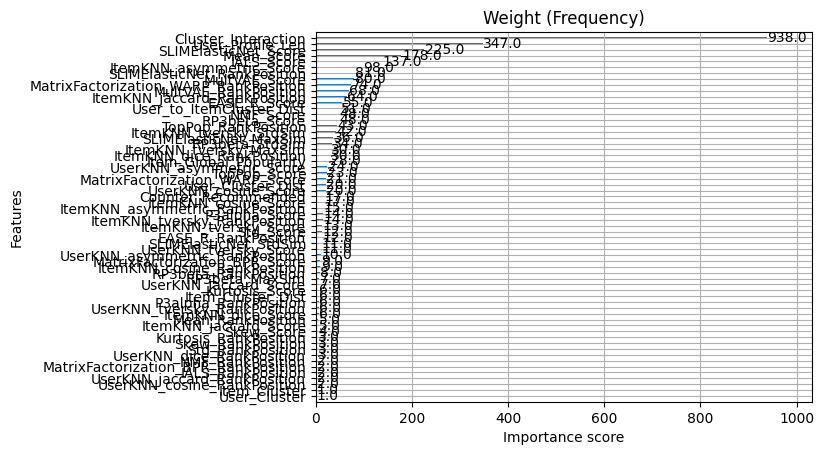

In [16]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')

## **Baseline without high correlated columns (> 0.9)**

In [17]:
cols_to_drop = ['ItemKNN_dice_Score', 'UserKNN_jaccard_Score', 'UserKNN_asymmetric_Score', 'UserKNN_tversky_Score', 'UserKNN_dice_Score', 'UserKNN_dice_Recommended', 'EASE_R_Score', 'Cluster_Interaction', 'User_to_ItemCluster_Dist', 'Kurtosis_RankPosition', 'User_Profile_Len', 'Item_Global_Popularity']

In [18]:
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_val = X_val.drop(columns=cols_to_drop, errors='ignore')

In [19]:
# Hyperparameters (Your baseline configuration)
n_estimators = 100
learning_rate = 1e-1
reg_alpha = 1e-1
reg_lambda = 1e-1
max_depth = 5
grow_policy = "depthwise"
objective = "pairwise" 

XGB_model = XGBRanker(objective='rank:{}'.format(objective),
                      n_estimators = int(n_estimators),
                      random_state = 42, # Fixed seed for reproducibility
                      learning_rate = learning_rate,
                      reg_alpha = reg_alpha,
                      reg_lambda = reg_lambda,
                      max_depth = int(max_depth),
                      max_leaves = 0,
                      grow_policy = grow_policy,
                      verbosity = 1, # Set to 1 to see training progress
                      booster = "gbtree",
                      n_jobs=-1, # Use all cores

                      enable_categorical=True,
                      callbacks=[ProgressCallback(n_estimators)]
                      )

In [20]:
print(f"Starting XGBRanker training with {len(groups)} user groups...")

XGB_model.fit(X_train,
              y_train,
              group=groups)

Starting XGBRanker training with 27095 user groups...
[Training] Tree 100/100

,objective,'rank:pairwise'
,base_score,None
,booster,'gbtree'
,callbacks,[<Challenge.XG...x7f3fd2ea9090>]
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [21]:
# Evaluate training performance
y_pred_scores = XGB_model.predict(X_train)
auc_score = roc_auc_score(y_train, y_pred_scores)
print(f"Training AUC Score: {auc_score:.4f}")

Training AUC Score: 0.7695


In [22]:
# Instantiate the recommender with the trained XGB model
recommender_instance = XGBoostRerankerRecommender(
    XGB_model=XGB_model,
    df=X_val
)
    
# Evaluate
score = evaluate_recommender(recommender_instance, at=20, URM_validation=URM_outer)
print(f"Validation Score (RECALL@20): {score:.4f}")

Eval Batches: 100%|██████████| 28/28 [00:02<00:00,  9.85it/s]

Validation Score (RECALL@20): 0.2942


## **Train native xgb**

In [23]:
dtrain = xgb.QuantileDMatrix(X_train, label=y_train, enable_categorical=True)
dtrain.set_group(groups)

In [24]:
import gc
del X_train, y_train, groups
gc.collect()

92

In [25]:
n_estimators   = 100
learning_rate  = 1e-1
reg_alpha      = 1e-1
reg_lambda     = 1e-1
max_depth      = 5
grow_policy    = "depthwise"
objective      = "pairwise"

params = {
    "objective": f"rank:{objective}",   # rank:pairwise
    "learning_rate": learning_rate,
    "reg_alpha": reg_alpha,
    "reg_lambda": reg_lambda,
    "max_depth": max_depth,
    "grow_policy": grow_policy,
    "max_leaves": 0,
    "booster": "gbtree",
    "verbosity": 1,
    "random_state": 42,
    "n_jobs": -1,

    "tree_method": "hist"
}

In [26]:
XGB_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=n_estimators,
    callbacks=[ProgressCallback(n_estimators)]
)

[Training] Tree 100/100

In [27]:
# Evaluate training performance
y_pred_scores = XGB_model.predict(dtrain)
y_train_true = dtrain.get_label()
auc_score = roc_auc_score(y_train_true, y_pred_scores)
print(f"Training AUC Score: {auc_score:.4f}")

Training AUC Score: 0.7695


In [28]:
# Instantiate the recommender with the trained XGB model
recommender_instance = XGBoostNativeRecommender(
    XGB_model=XGB_model,
    df=X_val
)
    
# Evaluate
score = evaluate_recommender(recommender_instance, at=20, URM_validation=URM_outer)
print(f"Validation Score (RECALL@20): {score:.4f}")

Indexing users...


Eval Batches: 100%|██████████| 28/28 [00:04<00:00,  5.96it/s]

Validation Score (RECALL@20): 0.2942
